In [3]:
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split

# --- PART 1: SETUP AND DATA LOADING --- 

base_dir = 'processed_data'
classes = ['cat', 'dog', 'rabbit', 'chicken']
final_data_dir = 'final_data'

# CHECK: Does the dataset folder exist?
if not os.path.exists(base_dir):
    print(f"❌ ERROR: The folder '{base_dir}' was not found. Please create it!")
else:
    # 1. Create Train/Test Folders 
    for split in ['train', 'test']:
        for cls in classes:
            os.makedirs(os.path.join(final_data_dir, split, cls), exist_ok=True)

    # 2. Split Data (80% Train / 20% Test) 
    for cls in classes:
        src_path = os.path.join(base_dir, cls)
        
        if not os.path.exists(src_path):
            print(f"❌ ERROR: Missing folder: {src_path}")
            continue
            
        images = [f for f in os.listdir(src_path) if os.path.isfile(os.path.join(src_path, f))]
        
        # Stratified sampling ensures equal representation 
        train_imgs, test_imgs = train_test_split(
            images, test_size=0.20, stratify=[cls]*len(images), random_state=42
        )
        
        # Copying files to 'final_data' folder 
        for img in train_imgs:
            shutil.copy(os.path.join(src_path, img), os.path.join(final_data_dir, 'train', cls, img))
        for img in test_imgs:
            shutil.copy(os.path.join(src_path, img), os.path.join(final_data_dir, 'test', cls, img))

    print("✅ Part 1 Complete: 'final_data' folder created with 640 train and 160 test images.") 

✅ Part 1 Complete: 'final_data' folder created with 640 train and 160 test images.


Part 1 Complete: Dataset split into 'final_data' folder.


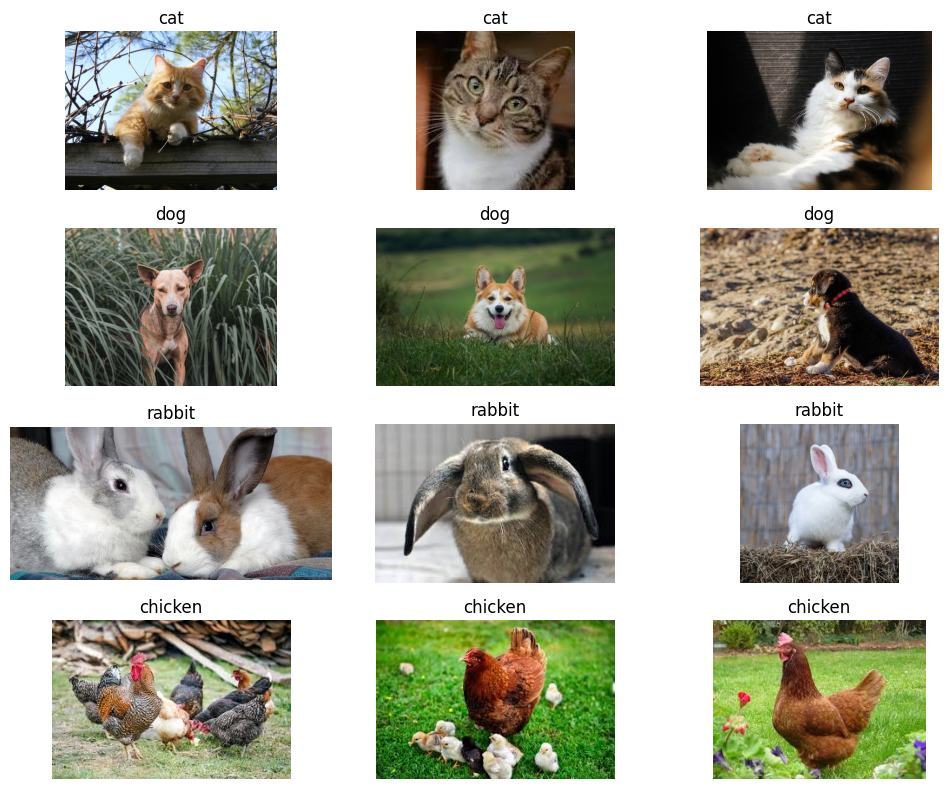

Found 640 images belonging to 4 classes.
Found 160 images belonging to 4 classes.
Found 320 images belonging to 4 classes.


In [4]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# --- PART 1: SETUP AND DATA LOADING --- 

# 1. Define paths
base_dir = 'processed_data'
classes = ['cat', 'dog', 'rabbit', 'chicken']
final_data_dir = 'final_data' # 

# 2. Create Train/Test Folders
for split in ['train', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(final_data_dir, split, cls), exist_ok=True)

# 3. Stratified Split (80% Train, 20% Test)
for cls in classes:
    src_path = os.path.join(base_dir, cls)
    images = os.listdir(src_path)
    
    # Split the 200 images per class
    train_imgs, test_imgs = train_test_split(
        images, test_size=0.20, stratify=[cls]*len(images), random_state=42
    )
    
    # Move files to final_data folder 
    for img in train_imgs:
        shutil.copy(os.path.join(src_path, img), os.path.join(final_data_dir, 'train', cls, img))
    for img in test_imgs:
        shutil.copy(os.path.join(src_path, img), os.path.join(final_data_dir, 'test', cls, img))

print("Part 1 Complete: Dataset split into 'final_data' folder.")

# --- PART 2: DATA PREVIEW AND PIPELINE --- 

# 1. Visualization: Display 3 random samples from each class 
def preview_images():
    plt.figure(figsize=(10, 8))
    for i, cls in enumerate(classes):
        cls_path = os.path.join(final_data_dir, 'train', cls)
        sample_imgs = np.random.choice(os.listdir(cls_path), 3)
        for j, img_name in enumerate(sample_imgs):
            plt.subplot(len(classes), 3, i*3 + j + 1)
            img = plt.imread(os.path.join(cls_path, img_name))
            plt.imshow(img)
            plt.title(cls)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

preview_images()

# 2. Keras Data Generators 
# Note: Resize to 64x64 and normalize pixel values 
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2 # 20% of train set for validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(final_data_dir, 'train'),
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    os.path.join(final_data_dir, 'train'),
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(final_data_dir, 'test'),
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical'
)

Import Libraries & Paths,Parameter

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

TRAIN_DIR = "final_data/train"
TEST_DIR = "final_data/test"

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
MAX_EPOCHS = 30


Data Generators

where training,validation and test sets are defined

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    validation_split=0.2   # 80% train, 20% validation
)

test_datagen = ImageDataGenerator(rescale=1./255)


Training Set

In [7]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)


Found 640 images belonging to 4 classes.


Validation Set

To monitor performance

In [8]:
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 160 images belonging to 4 classes.


Test Set

In [9]:
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 320 images belonging to 4 classes.


Build CNN Model

In [10]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,092 (6.20 MB)

 Trainable params: 1,625,092 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_generator,              # TRAINING SET
    validation_data=val_generator,# VALIDATION SET
    epochs=MAX_EPOCHS,
    callbacks=[early_stop]
)


Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.2516 - loss: 1.4240 - val_accuracy: 0.3000 - val_loss: 1.3819
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.3250 - loss: 1.3687 - val_accuracy: 0.3250 - val_loss: 1.3471
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.3438 - loss: 1.3208 - val_accuracy: 0.3313 - val_loss: 1.3096
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.3609 - loss: 1.3085 - val_accuracy: 0.3500 - val_loss: 1.2752
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.4000 - loss: 1.2839 - val_accuracy: 0.3562 - val_loss: 1.2750
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.4187 - loss: 1.2710 - val_accuracy: 0.3938 - val_loss: 1.2377
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.4437 - loss: 1.2172 - val_accuracy: 0.4313 - val_loss: 1.2288
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.4766 - loss: 1.2050 - val_accuracy: 0.4313 - val_loss:

Save trained Model

In [13]:
model.save("model_cnn.h5")


Evaluate using Test Set

In [14]:
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)


10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 607ms/step - accuracy: 0.7031 - loss: 0.7927
Test Accuracy: 0.703125


Training Graph

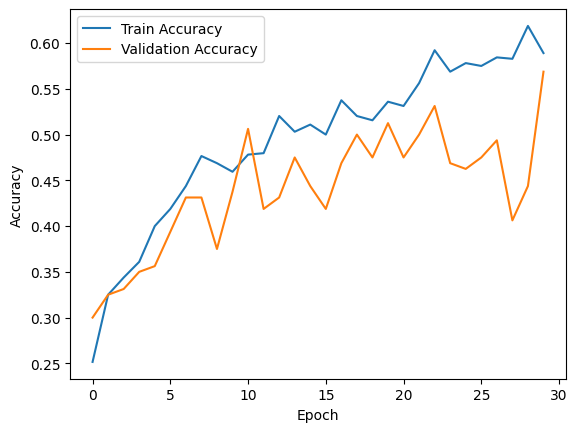

In [15]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()
